In [4]:
# ============================================================
# Cell 1: Setup
# ============================================================
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import torch
from pathlib import Path
from train import run_kfold

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

ROSE1 = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1")
PREP  = Path("/users/egottfri/code/octa-segmentation/data/preprocessed")  # now the tile=4 version

Device: cuda


In [5]:
# ============================================================
# Cell 2: RAW U-Net
# ============================================================
train_imgs  = sorted((ROSE1 / "SVC/train/img").glob("*.tif"))
train_masks = sorted((ROSE1 / "SVC/train/gt").glob("*.tif"))
test_imgs   = sorted((ROSE1 / "SVC/test/img").glob("*.tif"))
test_masks  = sorted((ROSE1 / "SVC/test/gt").glob("*.tif"))

scores_raw = run_kfold(
    train_imgs, train_masks, test_imgs, test_masks,
    n_splits=5, num_epochs=100, patience=10, batch_size=4, lr=1e-4,
    device=device, output_dir='results/unet_svc_raw'
)


FOLD 1/5
Epoch 1/100 | train_loss: 0.6073 | val_loss: 0.6936 | val_dice: 0.0000
New best! Saved (val_dice: 0.0000)
Epoch 2/100 | train_loss: 0.5178 | val_loss: 0.6648 | val_dice: 0.0000
Epoch 3/100 | train_loss: 0.4877 | val_loss: 0.6202 | val_dice: 0.0222
New best! Saved (val_dice: 0.0222)
Epoch 4/100 | train_loss: 0.4686 | val_loss: 0.5763 | val_dice: 0.1945
New best! Saved (val_dice: 0.1945)
Epoch 5/100 | train_loss: 0.4539 | val_loss: 0.5195 | val_dice: 0.4570
New best! Saved (val_dice: 0.4570)
Epoch 6/100 | train_loss: 0.4414 | val_loss: 0.4526 | val_dice: 0.5896
New best! Saved (val_dice: 0.5896)
Epoch 7/100 | train_loss: 0.4294 | val_loss: 0.4191 | val_dice: 0.6938
New best! Saved (val_dice: 0.6938)
Epoch 8/100 | train_loss: 0.4217 | val_loss: 0.4019 | val_dice: 0.7343
New best! Saved (val_dice: 0.7343)
Epoch 9/100 | train_loss: 0.4129 | val_loss: 0.3963 | val_dice: 0.7526
New best! Saved (val_dice: 0.7526)
Epoch 10/100 | train_loss: 0.4070 | val_loss: 0.4049 | val_dice: 0.7459

In [6]:
# ============================================================
# Cell 3: PREPROCESSED U-Net (optimal params)
# ============================================================
train_imgs  = sorted((PREP  / "SVC/train/img").glob("*.tif"))
train_masks = sorted((ROSE1 / "SVC/train/gt").glob("*.tif"))   # masks always original
test_imgs   = sorted((PREP  / "SVC/test/img").glob("*.tif"))
test_masks  = sorted((ROSE1 / "SVC/test/gt").glob("*.tif"))

scores_prep = run_kfold(
    train_imgs, train_masks, test_imgs, test_masks,
    n_splits=5, num_epochs=100, patience=10, batch_size=4, lr=1e-4,
    device=device, output_dir='results/unet_svc_preprocessed'
)


FOLD 1/5
Epoch 1/100 | train_loss: 0.6258 | val_loss: 0.7123 | val_dice: 0.3312
New best! Saved (val_dice: 0.3312)
Epoch 2/100 | train_loss: 0.5447 | val_loss: 0.6782 | val_dice: 0.3978
New best! Saved (val_dice: 0.3978)
Epoch 3/100 | train_loss: 0.5083 | val_loss: 0.6333 | val_dice: 0.2824
Epoch 4/100 | train_loss: 0.4910 | val_loss: 0.5844 | val_dice: 0.2462
Epoch 5/100 | train_loss: 0.4758 | val_loss: 0.5431 | val_dice: 0.3089
Epoch 6/100 | train_loss: 0.4653 | val_loss: 0.5027 | val_dice: 0.4900
New best! Saved (val_dice: 0.4900)
Epoch 7/100 | train_loss: 0.4548 | val_loss: 0.4487 | val_dice: 0.6860
New best! Saved (val_dice: 0.6860)
Epoch 8/100 | train_loss: 0.4479 | val_loss: 0.4269 | val_dice: 0.7244
New best! Saved (val_dice: 0.7244)
Epoch 9/100 | train_loss: 0.4394 | val_loss: 0.4184 | val_dice: 0.7447
New best! Saved (val_dice: 0.7447)
Epoch 10/100 | train_loss: 0.4353 | val_loss: 0.4295 | val_dice: 0.7398
Epoch 11/100 | train_loss: 0.4285 | val_loss: 0.4186 | val_dice: 0.74

In [15]:
# ============================================================
# Cell 4: Test-set evaluation for both
# ============================================================
from test_model import evaluate_on_test   # or wherever your U-Net evaluate_on_test lives

test_imgs_prep = sorted((PREP_BASE / "SVC/test/img").glob("*.tif"))
test_imgs_raw = sorted((ROSE1_BASE / "SVC/test/img").glob("*.tif"))
test_masks = sorted((ROSE1_BASE / "SVC/test/gt").glob("*.tif"))

# RAW
print("Raw:")
raw_models = [f"results/unet_svc_raw/best_model_fold{i}.pth" for i in range(1, 6)]
raw_final, raw_std = evaluate_on_test(test_imgs_raw, test_masks, raw_models, device)

# PREPROCESSED
print("\nPreprocessed:")
prep_models = [f"results/unet_svc_preprocessed/best_model_fold{i}.pth" for i in range(1, 6)]
prep_final, prep_std = evaluate_on_test(test_imgs_prep, test_masks, prep_models, device)

Raw:
Fold 1: dice=0.7742, iou=0.6340, sensitivity=0.7679, specificity=0.9521, precision=0.7852, auprc=0.8666
Fold 2: dice=0.7756, iou=0.6362, sensitivity=0.7633, specificity=0.9545, precision=0.7929, auprc=0.8649
Fold 3: dice=0.7741, iou=0.6341, sensitivity=0.7702, specificity=0.9506, precision=0.7823, auprc=0.8680
Fold 4: dice=0.7759, iou=0.6364, sensitivity=0.7639, specificity=0.9551, precision=0.7932, auprc=0.8669
Fold 5: dice=0.7708, iou=0.6299, sensitivity=0.7397, specificity=0.9600, precision=0.8094, auprc=0.8628

TEST SET RESULTS (mean ± std across folds)
dice: 0.7741 ± 0.0018
iou: 0.6341 ± 0.0023
sensitivity: 0.7610 ± 0.0109
specificity: 0.9545 ± 0.0032
precision: 0.7926 ± 0.0094
auprc: 0.8658 ± 0.0018

Preprocessed:
Fold 1: dice=0.7701, iou=0.6286, sensitivity=0.7503, specificity=0.9572, precision=0.7971, auprc=0.8592
Fold 2: dice=0.7658, iou=0.6230, sensitivity=0.7537, specificity=0.9531, precision=0.7842, auprc=0.8593
Fold 3: dice=0.7685, iou=0.6264, sensitivity=0.7716, spec

Raw:

Preprocessed:


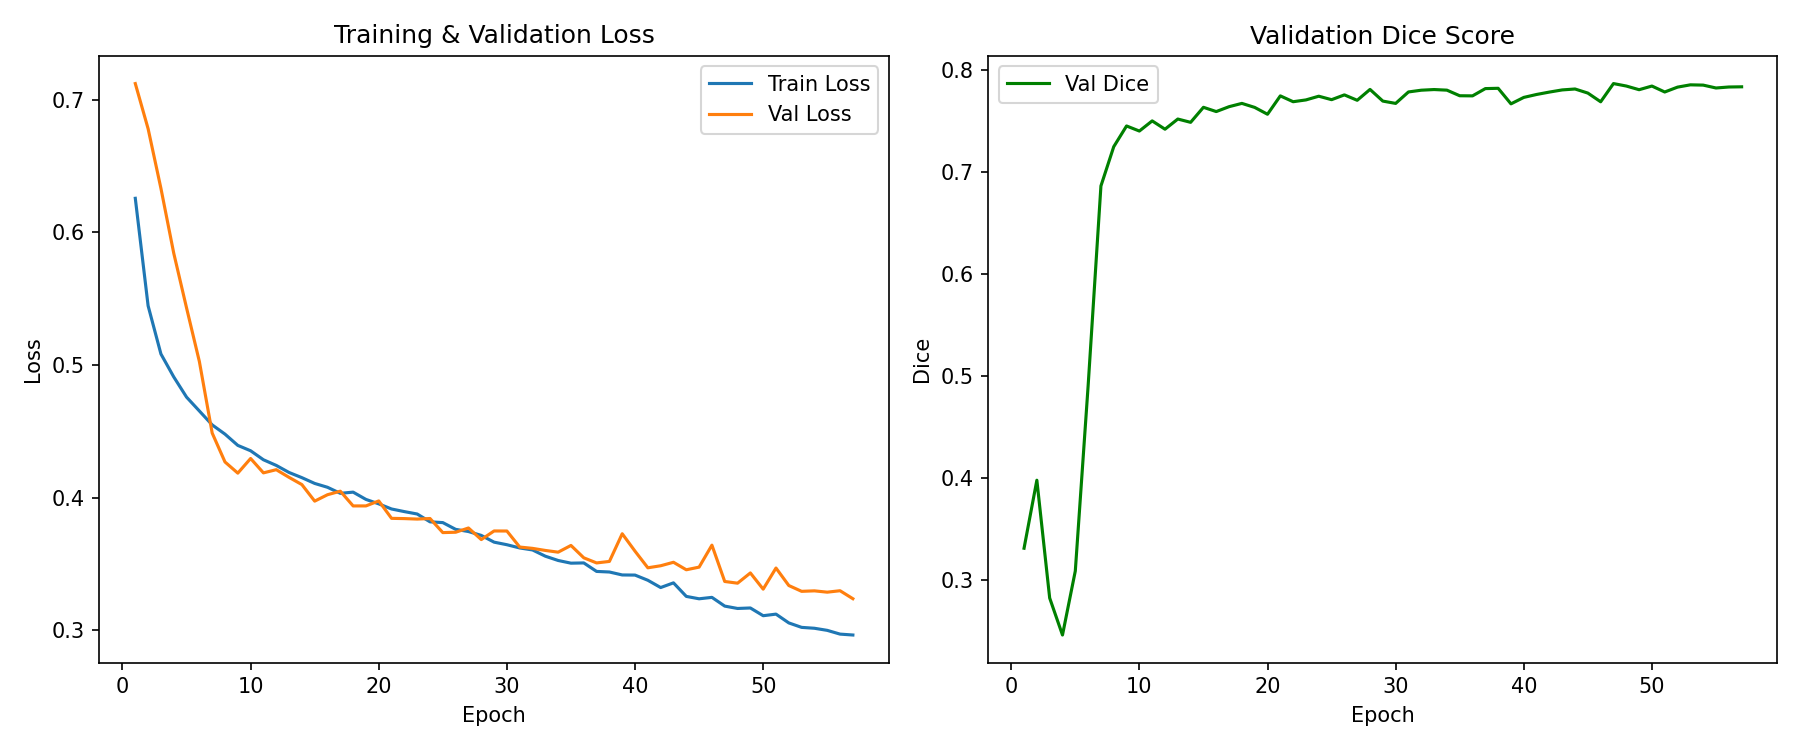

In [17]:
from IPython.display import Image
print("Raw:")
Image(filename='results/unet_svc_raw/training_curve_fold1.png')
print("\nPreprocessed:")
Image(filename='results/unet_svc_preprocessed/training_curve_fold1.png')


In [8]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')
from evaluate import evaluate
from model import UNet
from dataset import ROSEDataset
from torch.utils.data import DataLoader
import torch
import numpy as np


def evaluate_on_test(test_imgs, test_masks, model_paths, device='cuda'):
    """
    Evaluate saved fold models on the held-out test set.
    Returns averaged metrics across all folds.
    """
    test_ds = ROSEDataset(test_imgs, test_masks, augment=False)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    all_fold_metrics = []

    for fold_idx, model_path in enumerate(model_paths):
        model = UNet(in_channels=1, num_classes=1).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        fold_metrics = []
        with torch.no_grad():
            for images, masks in test_loader:
                images = images.to(device)
                logits = model(images)
                probs = torch.sigmoid(logits)

                pred = probs.cpu().numpy().squeeze()
                gt = masks.cpu().numpy().squeeze()
                pred_binary = (pred > 0.5).astype(np.uint8)

                metrics = evaluate(pred_binary, gt, prob_map=pred)
                fold_metrics.append(metrics)

        avg = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
        all_fold_metrics.append(avg)
        print(f"Fold {fold_idx+1}: " +
              ", ".join(f"{k}={v:.4f}" for k, v in avg.items()))

    final = {k: np.mean([fm[k] for fm in all_fold_metrics]) for k in all_fold_metrics[0]}
    std = {k: np.std([fm[k] for fm in all_fold_metrics]) for k in all_fold_metrics[0]}

    print("\n=== TEST SET RESULTS (mean ± std across folds) ===")
    for k in final:
        print(f"{k}: {final[k]:.4f} ± {std[k]:.4f}")

    return final, std

In [9]:
from pathlib import Path

PREP_BASE = Path("/users/egottfri/code/octa-segmentation/data/preprocessed")
ROSE1_BASE = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1")

test_imgs = sorted((PREP_BASE / "SVC/test/img").glob("*.tif"))
test_masks = sorted((ROSE1_BASE / "SVC/test/gt").glob("*.tif"))

model_paths = [f"results/unet_svc_preprocessed/best_model_fold{i}.pth" for i in range(1, 6)]

final_metrics, final_std = evaluate_on_test(test_imgs, test_masks, model_paths)

Fold 1: dice=0.7701, iou=0.6286, sensitivity=0.7503, specificity=0.9572, precision=0.7971, auprc=0.8592
Fold 2: dice=0.7658, iou=0.6230, sensitivity=0.7537, specificity=0.9531, precision=0.7842, auprc=0.8593
Fold 3: dice=0.7685, iou=0.6264, sensitivity=0.7716, specificity=0.9476, precision=0.7703, auprc=0.8643
Fold 4: dice=0.7698, iou=0.6282, sensitivity=0.7519, specificity=0.9551, precision=0.7933, auprc=0.8642
Fold 5: dice=0.7698, iou=0.6283, sensitivity=0.7530, specificity=0.9548, precision=0.7920, auprc=0.8636

=== TEST SET RESULTS (mean ± std across folds) ===
dice: 0.7688 ± 0.0016
iou: 0.6269 ± 0.0021
sensitivity: 0.7561 ± 0.0079
specificity: 0.9536 ± 0.0033
precision: 0.7874 ± 0.0095
auprc: 0.8621 ± 0.0024
